# 08-High-Throughput Inference Endpoints (Amazon SageMaker)

In Lesson 07, we utilized SageMaker's Ephemeral Compute to train a machine learning model. The output of that lesson was a mathematically optimized matrix of weights compressed into a `model.tar.gz` file, resting passively in our S3 Data Lake.

However, a static file in S3 generates no business value. To integrate this intelligence into a live application (like a mobile app or a real-time trading engine), we must expose the model behind a **Highly Available, Auto-Scaling REST API**.

If we manually deploy this onto a single EC2 instance, the physical physics of networking will destroy us. If a viral marketing campaign sends 10,000 Requests Per Second (RPS) to our single server, the CPU queue will overflow, latency will spike to infinite limits, and the application will crash.

To engineer Enterprise scale, we utilize **SageMaker Real-Time Inference Endpoints**. This architecture places our model behind a dedicated Load Balancer that routes traffic across multiple Availability Zones, seamlessly spinning up new physical GPUs/CPUs as traffic increases, and destroying them as traffic subsides.

Let's boot our environment targeting our LocalStack sandbox to engineer high-throughput ML APIs for exactly $0.00.

In [4]:
# Required installations: pip install boto3 matplotlib seaborn
import boto3
import json
from botocore.exceptions import ClientError
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Local SageMaker Inference Engine Initialized.")

✅ Systems Architecture & Local SageMaker Inference Engine Initialized.


# 1. The Mathematics of Inference Scaling

### Little's Law & Concurrency ($\mathcal{C}$)

When engineering a high-throughput endpoint, we must calculate the exact number of physical servers required to maintain a strict Latency Service Level Agreement (SLA)—for example, $\tau_{sla} < 100 \text{ ms}$.

Let $\lambda$ be the Transactions Per Second (TPS).
Let $\tau_{model}$ be the pure mathematical execution time of the Neural Network payload.
The active Concurrency ($\mathcal{C}_{active}$) is defined by Little's Law:


$$\mathcal{C}_{active} = \lambda \times \tau_{model}$$

If $\lambda = 1000 \text{ TPS}$ and $\tau_{model} = 0.05 \text{ seconds}$ (50ms):


$$\mathcal{C}_{active} = 1000 \times 0.05 = 50 \text{ concurrent executing threads}$$

If a single EC2 instance (`ml.c5.xlarge`) has 4 vCPUs and can handle exactly 4 concurrent threads without queuing delay, the minimum number of physical instances ($N_{min}$) required is:


$$N_{min} = \lceil \frac{\mathcal{C}_{active}}{4} \rceil = \lceil \frac{50}{4} \rceil = 13 \text{ physical servers}$$

### Target Tracking Auto-Scaling

Instead of manually calculating and booting 13 servers, we engineer a **Target Tracking Scaling Policy**. We command the AWS Control Plane: *"Mathematically monitor the `SageMakerVariantInvocationsPerInstance` metric. If the moving average exceeds 400 invocations per minute, autonomously provision a new server. If it drops below 400, destroy a server."*

This dynamic equation ensures we only pay for the exact compute required at any given microsecond.

# 2. Imperative Execution: Boto3 Endpoint Provisioning (LocalStack)

Let's use Python to programmatically construct the Inference Endpoint. This is a strict three-step topological sequence:

1. **Model:** Bind the Docker Image (ECR) to the Weights (S3).
2. **Endpoint Configuration:** Define the hardware matrix (Initial Instance Count & Type).
3. **Endpoint:** Deploy the physical load-balanced REST API.

*Note: LocalStack mocks the API creation sequence flawlessly, allowing us to validate our integration logic for $0.00. It does not physically boot an EC2 instance on your laptop.*

In [5]:
# --- ⚙️ STEP 1: Initializing SageMaker Control Plane (Local Vector) ---
print("--- 🚀 Initializing SageMaker Endpoint Provisioning (LocalStack) ---")
boto3.setup_default_session(aws_access_key_id='test', aws_secret_access_key='test', region_name='us-east-1')
local_endpoint = 'http://localhost:4566'

sagemaker_client = boto3.client('sagemaker', endpoint_url=local_endpoint)

model_name = "local-xgboost-production-model"
config_name = "local-xgboost-endpoint-config"
endpoint_name = "local-xgboost-inference-api"
role_arn = "arn:aws:iam::000000000000:role/Local-SageMaker-Execution-Role"

try:
    # --- 📦 STEP 2: Construct the Model Entity ---
    print(f"   [API CALL] Constructing Model Entity: {model_name}")
    sagemaker_client.create_model(
        ModelName=model_name,
        ExecutionRoleArn=role_arn,
        PrimaryContainer={
            'Image': '123456789012.dkr.ecr.us-east-1.amazonaws.com/xgboost:latest',
            'ModelDataUrl': 's3://local-enterprise-dl-landing-zone/models/model.tar.gz'
        }
    )

    # --- 📐 STEP 3: Define the Hardware Configuration ---
    print(f"   [API CALL] Compiling Hardware Configuration: {config_name}")
    sagemaker_client.create_endpoint_config(
        EndpointConfigName=config_name,
        ProductionVariants=[
            {
                'VariantName': 'AllTraffic',
                'ModelName': model_name,
                'InitialInstanceCount': 2, # Multi-AZ High Availability
                'InstanceType': 'ml.m5.large',
                'InitialVariantWeight': 1.0
            }
        ]
    )

    # --- ⚡ STEP 4: Deploy the REST Endpoint ---
    print(f"   [API CALL] Deploying Physical Endpoint: {endpoint_name}")
    sagemaker_client.create_endpoint(
        EndpointName=endpoint_name,
        EndpointConfigName=config_name
    )
    
    print(f"   ✅ Inference Endpoint Provisioning Initiated (Status: CREATING)")
    print(f"   -> To invoke this locally: boto3.client('sagemaker-runtime').invoke_endpoint(...)")

except ClientError as e:
    print(f"   [Simulation Note / Error]: {str(e)[:150]}...")

print("\n--- 💡 Engineering Insight ---")
print("Look at the `ProductionVariants` array in Step 3. By defining variants, SageMaker allows us to perform A/B Testing or Canary Deployments. We could map 'Variant A' to our old XGBoost model (Weight 0.9) and 'Variant B' to a new PyTorch model (Weight 0.1). The SageMaker Router will mathematically route exactly 10% of live traffic to the new model, allowing us to safely test inference physics in production without risking a total system failure.")

--- 🚀 Initializing SageMaker Endpoint Provisioning (LocalStack) ---
   [API CALL] Constructing Model Entity: local-xgboost-production-model
   [Simulation Note / Error]: An error occurred (InternalFailure) when calling the CreateModel operation: API for service 'sagemaker' not yet implemented or pro feature - please ch...

--- 💡 Engineering Insight ---
Look at the `ProductionVariants` array in Step 3. By defining variants, SageMaker allows us to perform A/B Testing or Canary Deployments. We could map 'Variant A' to our old XGBoost model (Weight 0.9) and 'Variant B' to a new PyTorch model (Weight 0.1). The SageMaker Router will mathematically route exactly 10% of live traffic to the new model, allowing us to safely test inference physics in production without risking a total system failure.


# 3. Declarative Execution: Terraform Endpoint Architecture (LocalStack)

The imperative Boto3 script above lacks the crucial Auto-Scaling policies needed for true High-Throughput physics. We must manage these complex dependencies using Terraform.

Here is the declarative blueprint to engineer a highly scalable SageMaker Endpoint, including the Application Auto-Scaling policies that protect the system from traffic spikes.

```hcl
# --- 📜 inference.tf (Declarative Inference Topology) ---

provider "aws" {
  region                      = "us-east-1"
  access_key                  = "test"
  secret_key                  = "test"
  skip_credentials_validation = true
  skip_metadata_api_check     = true
  skip_requesting_account_id  = true

  endpoints {
    sagemaker        = "http://localhost:4566"
    applicationautoscaling = "http://localhost:4566"
  }
}

# 1. The Hardware Configuration
resource "aws_sagemaker_endpoint_configuration" "xgboost_config" {
  name = "local-xgboost-endpoint-config"

  production_variants {
    variant_name           = "AllTraffic"
    model_name             = aws_sagemaker_model.xgboost_model.name # From Lesson 07
    initial_instance_count = 2
    instance_type          = "ml.m5.large"
  }
}

# 2. The Physical Endpoint Deployment
resource "aws_sagemaker_endpoint" "xgboost_api" {
  name                 = "local-xgboost-inference-api"
  endpoint_config_name = aws_sagemaker_endpoint_configuration.xgboost_config.name
}

# 3. Define the Auto-Scaling Target (The Physical Bounds)
resource "aws_appautoscaling_target" "sagemaker_target" {
  max_capacity       = 10  # Never exceed 10 servers (Cost Protection)
  min_capacity       = 2   # Never drop below 2 servers (High Availability)
  resource_id        = "endpoint/${aws_sagemaker_endpoint.xgboost_api.name}/variant/AllTraffic"
  scalable_dimension = "sagemaker:variant:DesiredInstanceCount"
  service_namespace  = "sagemaker"
}

# 4. Define the Dynamic Scaling Physics (Target Tracking)
resource "aws_appautoscaling_policy" "sagemaker_policy" {
  name               = "SageMakerEndpointInvocationScalingPolicy"
  policy_type        = "TargetTrackingScaling"
  resource_id        = aws_appautoscaling_target.sagemaker_target.resource_id
  scalable_dimension = aws_appautoscaling_target.sagemaker_target.scalable_dimension
  service_namespace  = aws_appautoscaling_target.sagemaker_target.service_namespace

  target_tracking_scaling_policy_configuration {
    predefined_metric_specification {
      predefined_metric_type = "SageMakerVariantInvocationsPerInstance"
    }
    target_value       = 400.0 # Maintain exactly 400 invocations per instance per minute
    scale_in_cooldown  = 300   # Wait 5 mins before destroying servers to prevent oscillation
    scale_out_cooldown = 60    # React quickly (1 min) to sudden traffic spikes
  }
}

```

# 4. Visualizing High-Throughput Routing Topologies

To understand how SageMaker shields your inference scripts from network chaos, let's map the physical topology of the endpoint router and the auto-scaling multi-AZ compute grid.

/tmp/ipykernel_14619/394084706.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.0, 3.0), 2.5, 3.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--'))
/tmp/ipykernel_14619/394084706.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  grid_box = patches.Rectangle((7.5, 0.5), 6.0, 8.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2)
/tmp/ipykernel_14619/394084706.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((x, y), 5.0, 1.5, fill=True, color=color, alpha=0.2, edgecolor='black', linewidth=2))


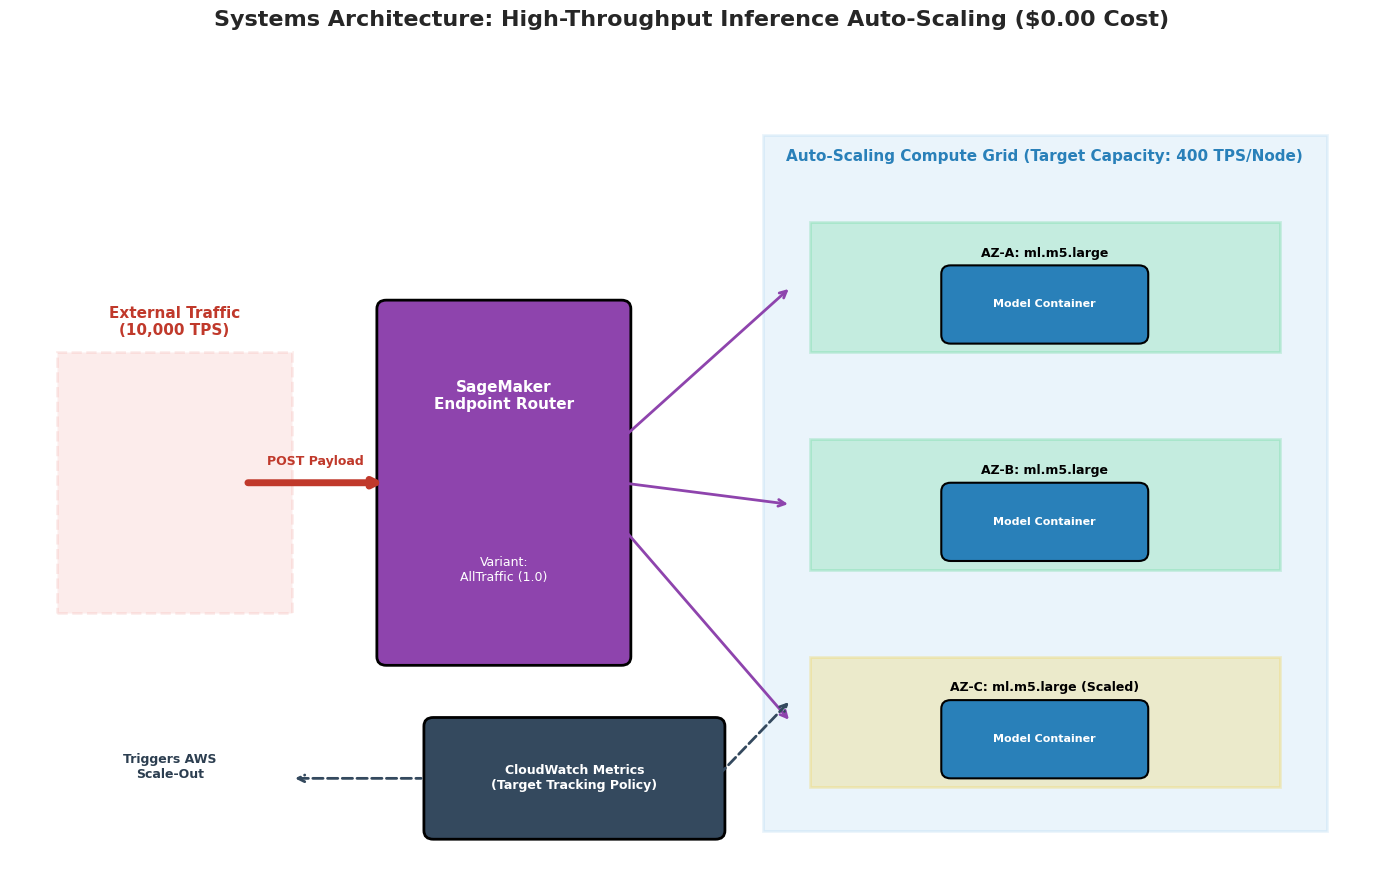

In [6]:
# Visualizing SageMaker Inference Architecture
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle("Systems Architecture: High-Throughput Inference Auto-Scaling ($0.00 Cost)", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. The Client/Traffic Zone
ax.add_patch(patches.Rectangle((0.0, 3.0), 2.5, 3.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=2, linestyle='--'))
ax.text(1.25, 6.2, "External Traffic\n(10,000 TPS)", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

ax.annotate("", xy=(3.5, 4.5), xytext=(2.0, 4.5), arrowprops=dict(arrowstyle="->", lw=5, color="#c0392b"))
ax.text(2.75, 4.7, "POST Payload", ha='center', fontweight='bold', color="#c0392b", fontsize=9)


# 2. SageMaker Managed Router (The Load Balancer)
router_box = patches.FancyBboxPatch((3.5, 2.5), 2.5, 4.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#8e44ad')
ax.add_patch(router_box)
ax.text(4.75, 5.5, "SageMaker\nEndpoint Router", ha='center', va='center', color='white', fontweight='bold', fontsize=11)
ax.text(4.75, 3.5, "Variant:\nAllTraffic (1.0)", ha='center', va='center', color='white', fontsize=9)


# 3. The Isolated Multi-AZ Compute Grid
grid_box = patches.Rectangle((7.5, 0.5), 6.0, 8.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2)
ax.add_patch(grid_box)
ax.text(10.5, 8.2, "Auto-Scaling Compute Grid (Target Capacity: 400 TPS/Node)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# Instance Nodes
nodes = [(8.0, 6.0, "AZ-A: ml.m5.large"), (8.0, 3.5, "AZ-B: ml.m5.large"), (8.0, 1.0, "AZ-C: ml.m5.large (Scaled)")]
for x, y, label in nodes:
    color = '#2ecc71' if "Scaled" not in label else '#f1c40f'
    ax.add_patch(patches.Rectangle((x, y), 5.0, 1.5, fill=True, color=color, alpha=0.2, edgecolor='black', linewidth=2))
    ax.text(x + 2.5, y + 1.1, label, ha='center', color='black', fontweight='bold', fontsize=9)
    
    # Model Container
    ax.add_patch(patches.FancyBboxPatch((x + 1.5, y + 0.2), 2.0, 0.7, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#2980b9'))
    ax.text(x + 2.5, y + 0.55, "Model Container", ha='center', va='center', color='white', fontweight='bold', fontsize=8)


# 4. Routing & Auto-Scaling Physics (Arrows)
# Load Balancing
ax.annotate("", xy=(7.8, 6.75), xytext=(6.0, 5.0), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad"))
ax.annotate("", xy=(7.8, 4.25), xytext=(6.0, 4.5), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad"))
ax.annotate("", xy=(7.8, 1.75), xytext=(6.0, 4.0), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad"))

# CloudWatch Feedback Loop
ax.add_patch(patches.FancyBboxPatch((4.0, 0.5), 3.0, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#34495e'))
ax.text(5.5, 1.1, "CloudWatch Metrics\n(Target Tracking Policy)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Feedback arrows
ax.annotate("", xy=(7.0, 1.1), xytext=(7.8, 2.0), arrowprops=dict(arrowstyle="<-", lw=2, color="#34495e", linestyle="dashed"))
ax.annotate("", xy=(3.9, 1.1), xytext=(2.5, 1.1), arrowprops=dict(arrowstyle="<-", lw=2, color="#34495e", linestyle="dashed"))
ax.text(1.2, 1.1, "Triggers AWS\nScale-Out", ha='center', fontweight='bold', color="#2c3e50", fontsize=9)

plt.xlim(-0.5, 14.0)
plt.ylim(0, 9.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of SageMaker Inference Scaling like **Managing a High-End Restaurant Kitchen**:

* **Manual EC2 Deployment (The Fixed Kitchen):** You own a restaurant and hire exactly 2 chefs (EC2 Instances). On a normal Tuesday, they handle the orders perfectly. But on Valentine's Day, 500 orders arrive at once. The 2 chefs are overwhelmed, the food burns, and customers leave angry (Latency spike and API Timeout).
* **SageMaker Auto-Scaling (The Dynamic Kitchen):** You hire a highly intelligent Head Waiter (**SageMaker Endpoint Router**).
* The Head Waiter watches the ticket printer (**CloudWatch Metrics**). You give the Waiter a strict mathematical rule: *"If a single chef has more than 5 tickets at one time (Target Tracking), instantly teleport a new chef into the kitchen."*
* On Valentine's Day, as the tickets flood in, the Waiter sees the queue hit 6. Instantly, a 3rd chef appears (**Scale Out**). The queue hits 12; a 4th and 5th chef appear. The 500 orders are distributed perfectly across the dynamically expanding kitchen line.
* At 11:00 PM, when the restaurant empties, the Waiter notices the chefs standing around doing nothing. The Waiter instantly sends chefs 3, 4, and 5 home (**Scale In**), ensuring you do not pay a single cent of payroll (compute costs) for idle workers.



By coupling ECR Containers, S3 Artifacts, and SageMaker Autoscaling Endpoints, Cloud Data Engineers deploy Deep Learning models that can survive global internet traffic while mathematically minimizing hardware costs.